In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

ARIMA_DATA = (
    PROJECT_ROOT
    / "data"
    / "arima"
)

RESULTS = PROJECT_ROOT / "results"

ARIMA_FORECASTS = (
    RESULTS
    / "arima_forecasts"
)

ARIMA_METRICS = (
    RESULTS
    / "arima_metrics"
)

ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
googl_arima = pd.read_csv(
    ARIMA_DATA / "GOOGL_arima.csv"
)

googl_arima["Date"] = pd.to_datetime(
    googl_arima["Date"]
)

googl_arima = (
    googl_arima
    .sort_values("Date")
    .reset_index(drop=True)
)

googl_arima.head()

,Date,Close,Log_Price,Log_Return
0,2004-08-19,2.49944,0.916067,NaN
1,2004-08-20,2.69798,0.992503,0.076437
2,2004-08-23,2.72512,1.002512,0.010009
3,2004-08-24,2.61228,0.960223,-0.042289
4,2004-08-25,2.64042,0.970938,0.010715


In [4]:
split_idx = int(
    len(googl_arima) * 0.8
)

train_df = googl_arima.iloc[
    :split_idx
].copy()

test_df = googl_arima.iloc[
    split_idx:
].copy()

In [5]:
print(
    "Train:",
    train_df["Date"].min(),
    "→",
    train_df["Date"].max()
)

print(
    "Test:",
    test_df["Date"].min(),
    "→",
    test_df["Date"].max()
)

print(
    "Train samples:",
    len(train_df)
)

print(
    "Test samples:",
    len(test_df)
)

Train: 2004-08-19 00:00:00 → 2022-03-24 00:00:00
Test: 2022-03-25 00:00:00 → 2026-08-25 00:00:00
Train samples: 4431
Test samples: 1108


In [6]:
train_log_price = (
    train_df["Log_Price"]
    .dropna()
)

train_log_return = (
    train_df["Log_Return"]
    .dropna()
)

In [7]:
result_price = adfuller(
    train_log_price
)

print("GOOGL Train Log Price")
print("ADF Statistic:", result_price[0])
print("p-value:", result_price[1])

GOOGL Train Log Price
ADF Statistic: -1.5764135480632915
p-value: 0.49542998393530285


In [8]:
result_return = adfuller(
    train_log_return
)

print("\nGOOGL Train Log Return")
print("ADF Statistic:", result_return[0])
print("p-value:", result_return[1])


GOOGL Train Log Return
ADF Statistic: -25.5000404541811
p-value: 0.0


In [ ]:
### Stationarity Result

The GOOGL training log-price series is non-stationary
(ADF p-value = 0.4954), while its first difference,
equivalent to log return, is stationary (p-value ≈ 0).

Therefore, first-order differencing is sufficient:

d = 1

<Figure size 1000x500 with 0 Axes>

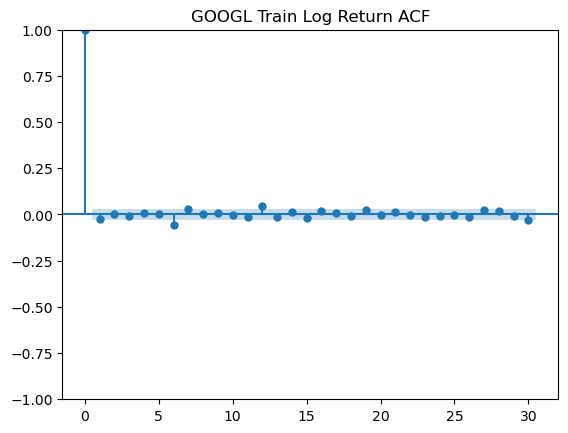

In [9]:
plt.figure(figsize=(10, 5))

plot_acf(
    train_log_return,
    lags=30
)

plt.title("GOOGL Train Log Return ACF")
plt.show()

<Figure size 1000x500 with 0 Axes>

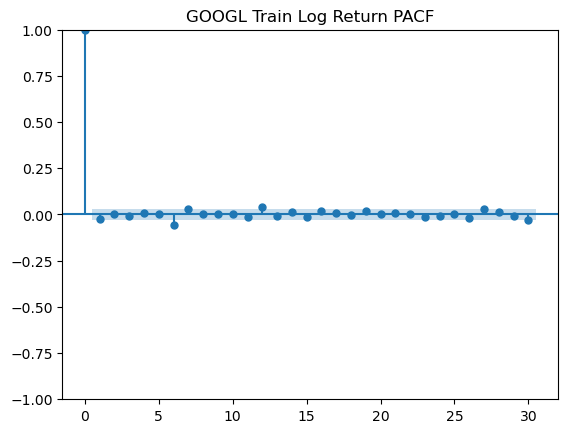

In [10]:
plt.figure(figsize=(10, 5))

plot_pacf(
    train_log_return,
    lags=30,
    method="ywm"
)

plt.title("GOOGL Train Log Return PACF")
plt.show()

In [ ]:
#GOOGL log returns exhibit weak and scattered autocorrelation, without a clear low-lag AR or MA structure.

In [17]:
candidate_orders = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]

In [18]:
comparison_results = []

for order in candidate_orders:

    model = ARIMA(
        train_log_price,
        order=order,
        trend="n"
    )

    fitted_model = model.fit()

    comparison_results.append({
        "Order": order,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "Converged": fitted_model.mle_retvals.get(
            "converged",
            True
        )
    })

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = (
    comparison_df
    .sort_values("AIC")
    .reset_index(drop=True)
)

comparison_df

,Order,AIC,BIC,Converged
0,"(0, 1, 0)",-22547.724180,-22541.328025,True
1,"(1, 1, 0)",-22547.569171,-22534.776862,True
2,"(0, 1, 1)",-22547.552597,-22534.760287,True
3,"(1, 1, 1)",-22545.744350,-22526.555885,True


In [ ]:
### GOOGL ARIMA Order Selection

The GOOGL training sample was used exclusively for model selection to avoid test-set leakage.

The ADF test showed that the log-price series is non-stationary, while the first-differenced log-price series, equivalent to log return, is stationary. Therefore:

d = 1

The ACF and PACF plots showed only weak and scattered autocorrelation, with no clear evidence supporting a high-order AR or MA structure.

Four low-order ARIMA specifications were therefore compared:

- ARIMA(0,1,0)
- ARIMA(1,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,1)

ARIMA(0,1,0) produced the lowest AIC and BIC, while all candidate models converged successfully.

Therefore, ARIMA(0,1,0) is selected as the GOOGL specification for out-of-sample forecasting.

This model will now be evaluated over the 30D, 3M, and 6M forecast horizons using calendar-aligned walk-forward forecasting.

In [19]:
GOOGL_ORDER = (0, 1, 0)

In [29]:
def create_arima_target(
    full_df,
    test_df,
    horizon
):
    horizon_map = {
        "30D": pd.Timedelta(days=30),
        "3M": pd.DateOffset(months=3),
        "6M": pd.DateOffset(months=6)
    }

    target_df = test_df[
        [
            "Date",
            "Close",
            "Log_Price"
        ]
    ].copy()

    target_df["Target_Date"] = (
        target_df["Date"]
        + horizon_map[horizon]
    )

    future_prices = full_df[
        [
            "Date",
            "Close",
            "Log_Price"
        ]
    ].copy()

    future_prices = future_prices.rename(
        columns={
            "Date": "Future_Date",
            "Close": "Future_Close",
            "Log_Price": "Future_Log_Price"
        }
    )

    target_df = pd.merge_asof(
        target_df.sort_values("Target_Date"),
        future_prices.sort_values("Future_Date"),
        left_on="Target_Date",
        right_on="Future_Date",
        direction="forward"
    )

    target_df = target_df.dropna(
        subset=[
            "Future_Date",
            "Future_Close"
        ]
    ).copy()

    return target_df

In [30]:
def calculate_arima_metrics(
    prediction_df,
    asset_name,
    horizon,
    model_name="ARIMA"
):
    y_true = prediction_df["Actual_Return"]
    y_pred = prediction_df["Predicted_Return"]

    # Main metrics
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    directional_accuracy = np.mean(
        np.sign(y_true.values)
        ==
        np.sign(y_pred.values)
    )

    # Zero-return baseline
    baseline_pred = np.zeros(
        len(y_true)
    )

    baseline_mae = mean_absolute_error(
        y_true,
        baseline_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_pred
        )
    )

    # Improvement vs baseline
    mae_improvement = (
        baseline_mae - mae
    )

    rmse_improvement = (
        baseline_rmse - rmse
    )

    # Raw metrics
    metrics_raw = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),

        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Directional_Accuracy": float(
            directional_accuracy
        ),

        "Baseline_MAE": float(
            baseline_mae
        ),
        "Baseline_RMSE": float(
            baseline_rmse
        ),

        "MAE_Improvement_vs_Baseline": float(
            mae_improvement
        ),
        "RMSE_Improvement_vs_Baseline": float(
            rmse_improvement
        )
    }

    # Display metrics
    metrics_display = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),

        "MAE_%": round(
            mae * 100,
            2
        ),

        "RMSE_%": round(
            rmse * 100,
            2
        ),

        "R2": round(
            r2,
            3
        ),

        "Directional_Accuracy_%": round(
            directional_accuracy * 100,
            2
        ),

        "Baseline_MAE_%": round(
            baseline_mae * 100,
            2
        ),

        "Baseline_RMSE_%": round(
            baseline_rmse * 100,
            2
        ),

        "MAE_Improvement_pp": round(
            mae_improvement * 100,
            2
        ),

        "RMSE_Improvement_pp": round(
            rmse_improvement * 100,
            2
        )
    }

    return metrics_raw, metrics_display

In [31]:
def run_arima_walk_forward(
    full_df,
    test_target_df,
    order,
    refit_every=5
):
    rolling_results = []

    fitted_model = None
    last_model_date = None

    non_converged = 0
    failed_windows = 0
    skipped_windows = 0
    refit_count = 0

    for i in range(len(test_target_df)):

        row = test_target_df.iloc[i]

        current_date = row["Date"]
        current_close = row["Close"]
        future_date = row["Future_Date"]
        future_close = row["Future_Close"]

        # --------------------------------------------------
        # 1. Count future trading observations
        # --------------------------------------------------

        forecast_dates = full_df[
            (full_df["Date"] > current_date)
            &
            (full_df["Date"] <= future_date)
        ]

        steps = len(forecast_dates)

        if steps == 0:
            skipped_windows += 1
            continue

        try:

            # --------------------------------------------------
            # 2. Full refit every 5 trading observations
            # --------------------------------------------------

            if fitted_model is None or i % refit_every == 0:

                history = full_df[
                    full_df["Date"] <= current_date
                ]["Log_Price"].dropna()

                # Convert to NumPy
                # Avoid statsmodels Pandas-index problems
                history_values = history.to_numpy(
                    dtype=float
                )

                model = ARIMA(
                    history_values,
                    order=order,
                    trend="n"
                )

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore",
                        ConvergenceWarning
                    )

                    fitted_model = model.fit()

                refit_count += 1

                last_model_date = current_date

                converged = (
                    fitted_model
                    .mle_retvals
                    .get("converged", True)
                )

                if not converged:
                    non_converged += 1

            # --------------------------------------------------
            # 3. Between refits:
            #    append newly observed prices
            # --------------------------------------------------

            else:

                new_data = full_df[
                    (full_df["Date"] > last_model_date)
                    &
                    (full_df["Date"] <= current_date)
                ]["Log_Price"].dropna()

                if len(new_data) > 0:

                    # Convert to NumPy
                    # This removes index-extension constraints
                    new_values = new_data.to_numpy(
                        dtype=float
                    )

                    fitted_model = (
                        fitted_model.append(
                            new_values,
                            refit=False
                        )
                    )

                last_model_date = current_date

            # --------------------------------------------------
            # 4. Forecast
            # --------------------------------------------------

            forecast_log = fitted_model.forecast(
                steps=steps
            )

            # Works whether forecast output is
            # ndarray or pandas Series
            predicted_log_price = (
                np.asarray(forecast_log)[-1]
            )

            # --------------------------------------------------
            # 5. Convert log price back to price
            # --------------------------------------------------

            predicted_future_price = np.exp(
                predicted_log_price
            )

            # --------------------------------------------------
            # 6. Calculate predicted and actual returns
            # --------------------------------------------------

            predicted_return = (
                predicted_future_price
                / current_close
                - 1
            )

            actual_return = (
                future_close
                / current_close
                - 1
            )

            # --------------------------------------------------
            # 7. Save result
            # --------------------------------------------------

            rolling_results.append({
                "Date": current_date,
                "Current_Close": current_close,
                "Future_Date": future_date,
                "Forecast_Steps": steps,
                "Actual_Future_Price": future_close,
                "Predicted_Future_Price": predicted_future_price,
                "Actual_Return": actual_return,
                "Predicted_Return": predicted_return
            })

        except Exception as e:

            failed_windows += 1

            print(
                f"Failed on {current_date}: {e}"
            )

    prediction_df = pd.DataFrame(
        rolling_results
    )

    diagnostics = {
        "Forecasts": len(prediction_df),
        "Refit_Count": refit_count,
        "Non_Converged": non_converged,
        "Skipped_Windows": skipped_windows,
        "Failed_Windows": failed_windows
    }

    return prediction_df, diagnostics

In [32]:
googl_horizons = [
    "30D",
    "3M",
    "6M"
]

googl_arima_predictions = {}
googl_metrics_raw = []
googl_metrics_display = []

for horizon in googl_horizons:

    print(
        f"Running GOOGL ARIMA {horizon}..."
    )

    target_df = create_arima_target(
        full_df=googl_arima,
        test_df=test_df,
        horizon=horizon
    )

    prediction_df, diagnostics = (
        run_arima_walk_forward(
            full_df=googl_arima,
            test_target_df=target_df,
            order=GOOGL_ORDER,
            refit_every=5
        )
    )

    metrics_raw, metrics_display = (
        calculate_arima_metrics(
            prediction_df=prediction_df,
            asset_name="GOOGL",
            horizon=horizon,
            model_name="ARIMA"
        )
    )

    googl_arima_predictions[
        horizon
    ] = prediction_df

    googl_metrics_raw.append(
        metrics_raw
    )

    googl_metrics_display.append(
        metrics_display
    )

    print(
        horizon,
        "completed:",
        len(prediction_df),
        "forecasts"
    )

Running GOOGL ARIMA 30D...
30D completed: 1086 forecasts
Running GOOGL ARIMA 3M...
3M completed: 1044 forecasts
Running GOOGL ARIMA 6M...
6M completed: 983 forecasts


In [33]:
googl_metrics_raw_df = pd.DataFrame(
    googl_metrics_raw
)

googl_metrics_display_df = pd.DataFrame(
    googl_metrics_display
)

googl_metrics_display_df

,Asset,Model,Horizon,Samples,MAE_%,RMSE_%,R2,Directional_Accuracy_%,Baseline_MAE_%,Baseline_RMSE_%,MAE_Improvement_pp,RMSE_Improvement_pp
0,GOOGL,ARIMA,30D,1086,7.34,9.25,-0.063,43.55,7.34,9.25,0.00,0.00
1,GOOGL,ARIMA,3M,1044,14.65,18.31,-0.239,42.24,14.64,18.30,-0.01,-0.01
2,GOOGL,ARIMA,6M,983,23.35,31.18,-0.469,44.05,23.35,31.18,0.00,0.00


In [34]:
GOOGL_ARIMA_FORECASTS = (
    ARIMA_FORECASTS
    / "GOOGL"
)

GOOGL_ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

In [35]:
for horizon, prediction_df in googl_arima_predictions.items():

    prediction_df.to_csv(
        GOOGL_ARIMA_FORECASTS
        / f"GOOGL_ARIMA_{horizon}_predictions.csv",
        index=False
    )

In [36]:
GOOGL_ARIMA_METRICS = (
    ARIMA_METRICS
    / "GOOGL"
)

GOOGL_ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)

In [37]:
googl_metrics_raw_df.to_csv(
    GOOGL_ARIMA_METRICS
    / "GOOGL_ARIMA_metrics_raw.csv",
    index=False
)

googl_metrics_display_df.to_csv(
    GOOGL_ARIMA_METRICS
    / "GOOGL_ARIMA_metrics_display.csv",
    index=False
)

In [ ]:
### GOOGL ARIMA Forecast Results

ARIMA(0,1,0) produced out-of-sample forecasts for the 30D, 3M, and 6M horizons.

Across all three horizons, ARIMA MAE and RMSE were almost identical to the zero-return baseline, with approximately zero improvement.

This is consistent with the ARIMA(0,1,0) specification. Without AR or MA terms and without drift, the model behaves approximately as a random-walk forecast, implying that the expected future price remains close to the current price.

R² remained negative across all horizons and became more negative as the forecast horizon increased, indicating limited ability to explain future-return variation.

Overall, the GOOGL ARIMA model does not demonstrate incremental predictive value beyond the no-change baseline.